In [1]:
import pandas as pd
import pathlib
import seaborn as sns
import numpy as np

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from krfp_models import name_to_model, name_to_pre_smarts, name_to_post_smarts, model_name_to_publication_name

from matplotlib import pyplot as plt

/home/dominik/MyStuff/bxaic2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
validation_datasets_path = pathlib.Path("data/validation_datasets")

dfs = {}

for file in validation_datasets_path.glob("*.csv"):
    df = pd.read_csv(file)
    dfs[file.stem] = df

In [3]:
for name, df in dfs.items():
    positives = df["ORIGIN"] == "POSITIVE"
    tversky_negatives = df["ORIGIN"] == "TVERSKY"
    negatives = df["ORIGIN"] == "NEGATIVE"

    print(f"{name}:")
    print(f"  Positives: {positives.sum()}")
    print(f"  Tversky Negatives: {tversky_negatives.sum()}")
    print(f"  Negatives: {negatives.sum()}")


MoleculeMDetector:
  Positives: 5000000
  Tversky Negatives: 13491
  Negatives: 4998512
MoleculeEDetector:
  Positives: 248
  Tversky Negatives: 118672
  Negatives: 4994354
MoleculeKDetector:
  Positives: 3376760
  Tversky Negatives: 2866888
  Negatives: 4859902
MoleculeODetector:
  Positives: 1970537
  Tversky Negatives: 717424
  Negatives: 4965399
MoleculeFDetector:
  Positives: 24
  Tversky Negatives: 1568016
  Negatives: 4925632
MoleculeGDetector:
  Positives: 1146
  Tversky Negatives: 569455
  Negatives: 4972881
MoleculeQDetector:
  Positives: 894517
  Tversky Negatives: 3950564
  Negatives: 4812155
MoleculePDetector:
  Positives: 286098
  Tversky Negatives: 127085
  Negatives: 4993947
MoleculeIDetector:
  Positives: 5000000
  Tversky Negatives: 5000000
  Negatives: 4729159
MoleculeNDetector:
  Positives: 5000000
  Tversky Negatives: 241794
  Negatives: 4985482
MoleculeHDetector:
  Positives: 34
  Tversky Negatives: 70609
  Negatives: 4996581
MoleculeJDetector:
  Positives: 886073

[12:15:54] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.


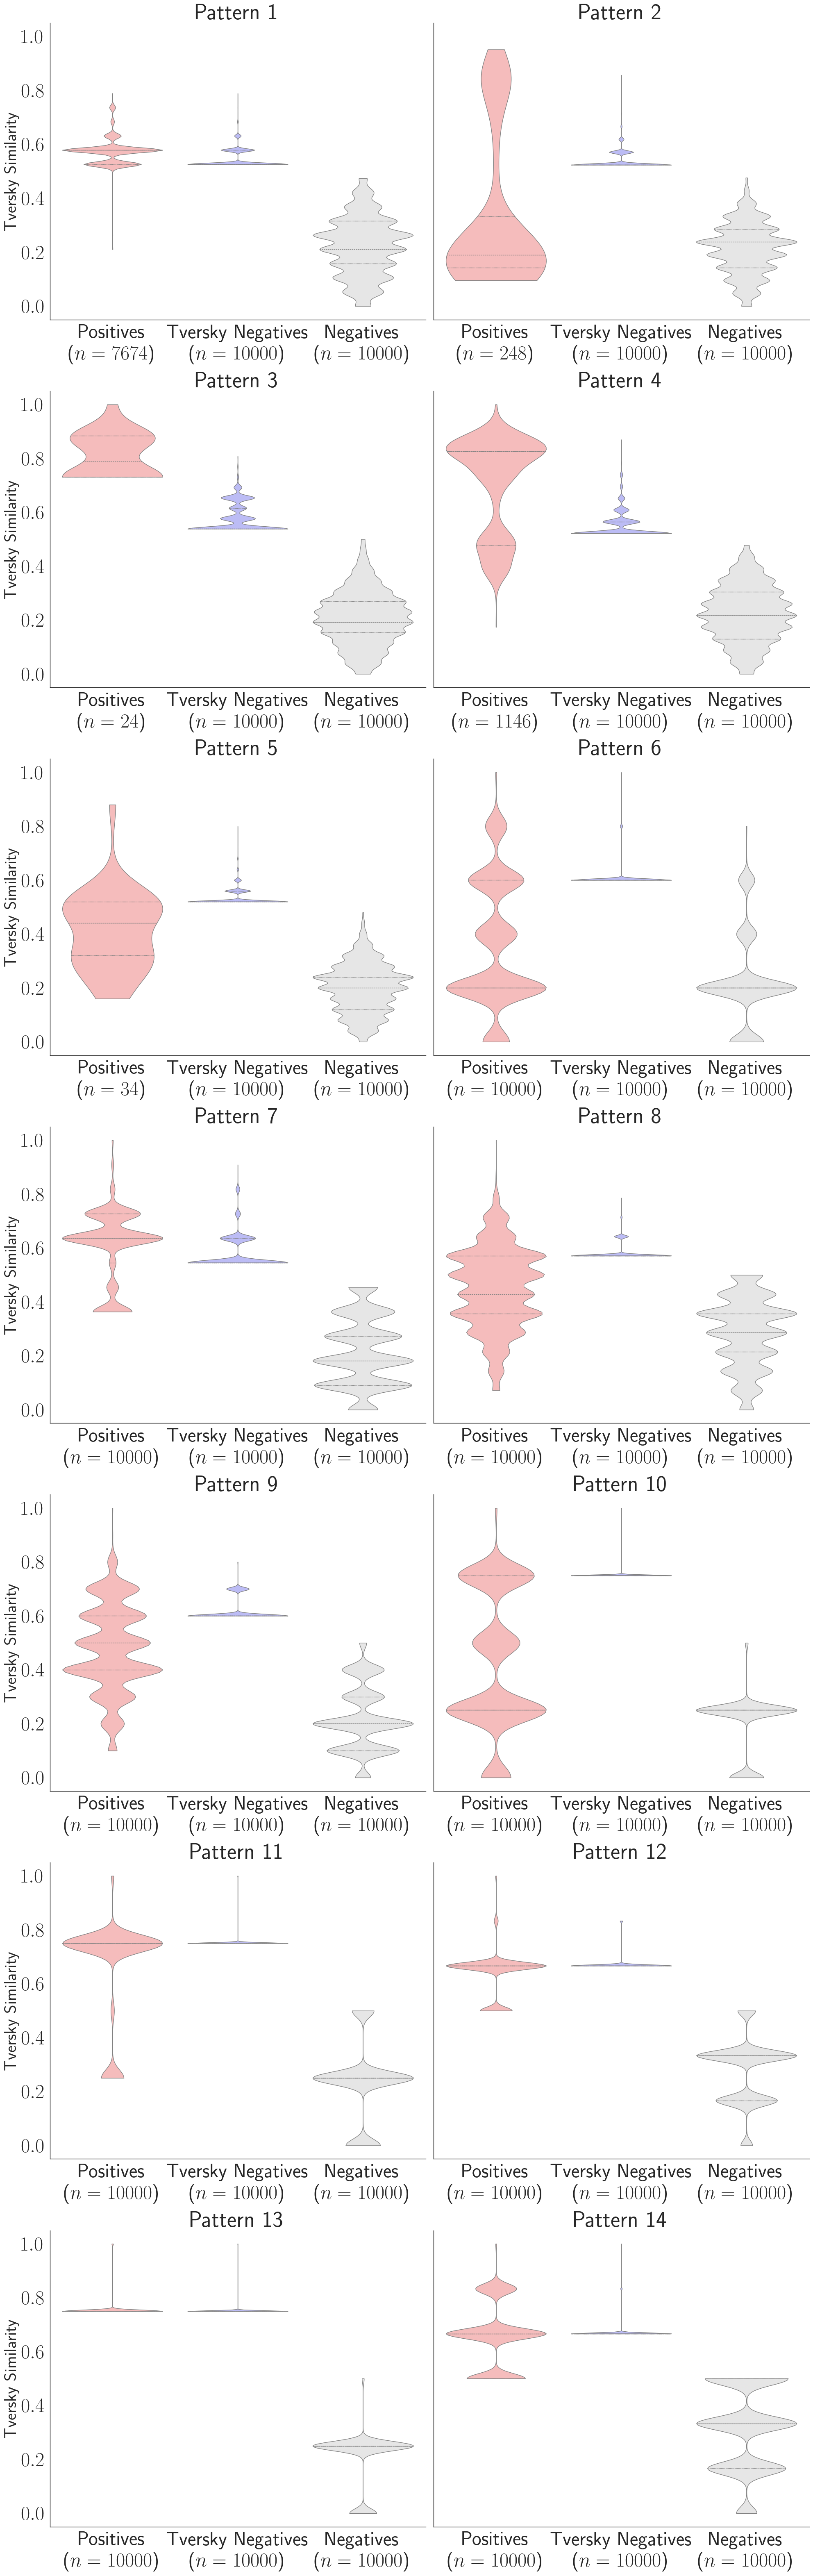

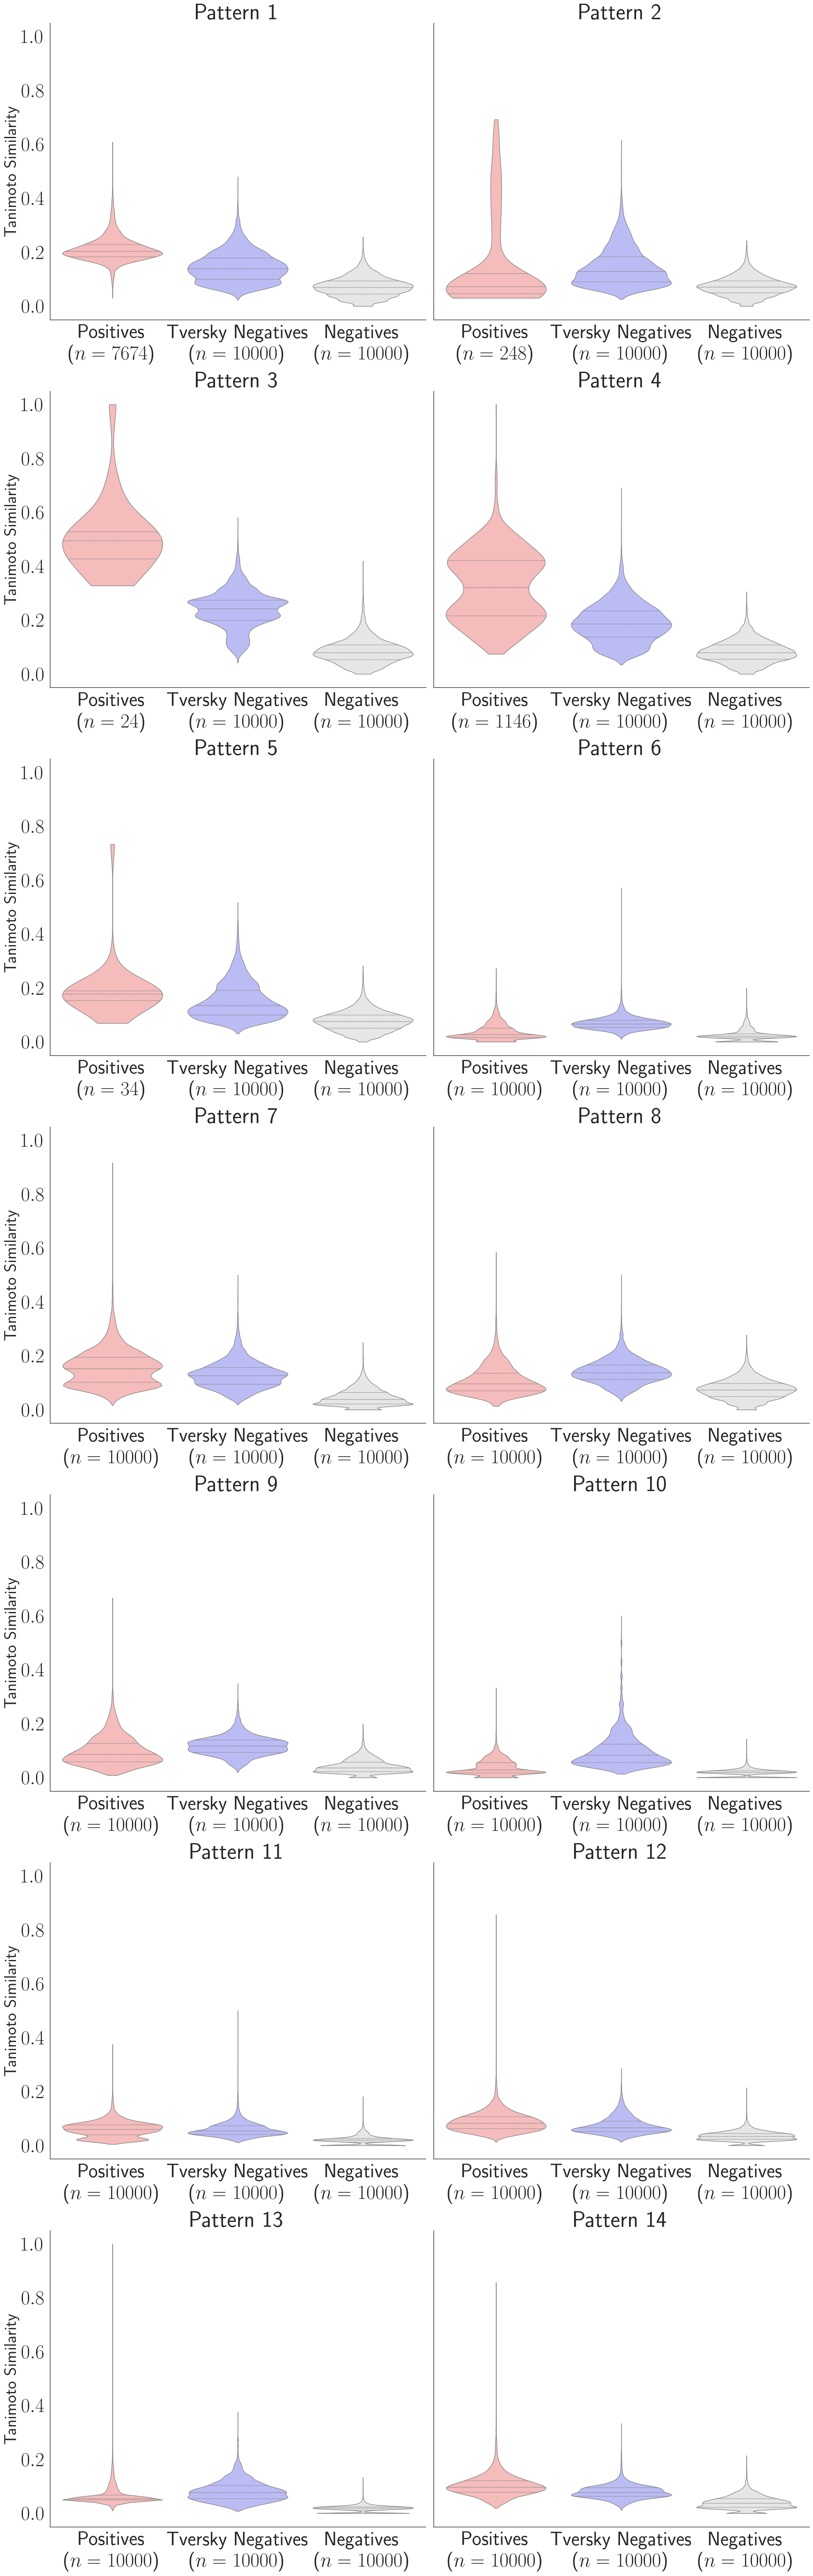

In [5]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2)


def map_mol_list_to_fingerprints(mol_list: list[Chem.Mol]):
    fps = []

    for mol in mol_list:
        fp = fpgen.GetFingerprint(mol)
        fp = list(fp)
        fp = np.array(fp, dtype=bool)
        fps.append(fp)

    return np.array(fps)


def tversky(fps, target_fp, alpha: float, beta: float):
    intersection = fps & target_fp
    only_in_prototype = target_fp & ~fps
    only_in_candidate = fps & ~target_fp

    intersection_sum = np.sum(intersection, axis=1)
    only_in_prototype_sum = np.sum(only_in_prototype, axis=1)
    only_in_candidate_sum = np.sum(only_in_candidate, axis=1)

    tversky_index = intersection_sum / (
            intersection_sum + alpha * only_in_prototype_sum + beta * only_in_candidate_sum + 1e-8)

    return tversky_index


plt.rcParams['text.usetex'] = True

paper_palette = ["#ffb2b2", "#b2b2ff", "#e6e6e6"]

fig_tversky, axes_tversky = plt.subplots(7, 2, figsize=(20, 70), sharey=True)
fig_tanimoto, axes_tanimoto = plt.subplots(7, 2, figsize=(20, 70), sharey=True)

#names_subset = ["MoleculeFDetector", "MoleculeQDetector"]
names_subset = dfs.keys()  # Use all names in the subset
dfs_subset = {name: df for name, df in dfs.items() if name in names_subset}
dfs_items = sorted(dfs_subset.items(), key=lambda x: x[0])

sns.set_context("paper", font_scale=1.2)
sns.set_style("white")

for ax_tversky, ax_tanimoto, (name, df) in zip(axes_tversky.flatten(), axes_tanimoto.flatten(),
                                               dfs_items):

    if name not in names_subset:
        continue

    positives = df["ORIGIN"] == "POSITIVE"
    tversky_negatives = df["ORIGIN"] == "TVERSKY"
    negatives = df["ORIGIN"] == "NEGATIVE"

    n = 10000

    positive_sample_size = min(n, positives.sum())
    tversky_sample_size = min(n, tversky_negatives.sum())
    negative_sample_size = min(n, negatives.sum())

    positives_sample = df[positives].sample(positive_sample_size, random_state=42)
    tversky_sample = df[tversky_negatives].sample(tversky_sample_size, random_state=42)
    negatives_sample = df[negatives].sample(negative_sample_size, random_state=42)

    positive_mols = [Chem.MolFromSmiles(s) for s in positives_sample["SMILES"]]
    tversky_mols = [Chem.MolFromSmiles(s) for s in tversky_sample["SMILES"]]
    negative_mols = [Chem.MolFromSmiles(s) for s in negatives_sample["SMILES"]]

    positive_fps = map_mol_list_to_fingerprints(positive_mols)
    tversky_fps = map_mol_list_to_fingerprints(tversky_mols)
    negative_fps = map_mol_list_to_fingerprints(negative_mols)

    smarts = name_to_pre_smarts[name]
    smarts_mol = Chem.MolFromSmarts(smarts)
    smarts_mol = Chem.RemoveAllHs(smarts_mol)
    smiles = Chem.MolToSmiles(smarts_mol, canonical=True)
    smiles = smiles.replace("*", "C")

    pattern_mol = Chem.MolFromSmiles(smiles)
    pattern_mol_fp = map_mol_list_to_fingerprints([pattern_mol])[0]

    positive_tversky = tversky(positive_fps, pattern_mol_fp, alpha=1, beta=0)
    tversky_tversky = tversky(tversky_fps, pattern_mol_fp, alpha=1, beta=0)
    negative_tversky = tversky(negative_fps, pattern_mol_fp, alpha=1, beta=0)

    positive_tanimoto = tversky(positive_fps, pattern_mol_fp, alpha=1, beta=1)
    tversky_tanimoto = tversky(tversky_fps, pattern_mol_fp, alpha=1, beta=1)
    negative_tanimoto = tversky(negative_fps, pattern_mol_fp, alpha=1, beta=1)

    assert np.min(tversky_tversky) >= 0.5, "Tversky negatives should have high similarity to the prototype"

    pattern_name = model_name_to_publication_name[name]

    sns.violinplot(
        {
            f"Positives \n($n={positive_sample_size}$)": positive_tversky,
            f"Tversky Negatives \n($n={tversky_sample_size}$)": tversky_tversky,
            f"Negatives \n($n={negative_sample_size}$)": negative_tversky
        }, common_norm=False,
        ax=ax_tversky,
        cut=0,
        palette=paper_palette,
        inner="quartile",
    )

    # Set axis y label 
    ax_tversky.set_ylabel("Tversky Similarity", fontsize=30)
    ax_tversky.set_title(pattern_name, fontsize=40)
    ax_tversky.xaxis.set_tick_params(labelsize=35)
    ax_tversky.yaxis.set_tick_params(labelsize=35)

    sns.violinplot(
        {
            f"Positives \n($n={positive_sample_size}$)": positive_tanimoto,
            f"Tversky Negatives \n($n={tversky_sample_size}$)": tversky_tanimoto,
            f"Negatives \n($n={negative_sample_size}$)": negative_tanimoto
        }, common_norm=False,
        ax=ax_tanimoto,
        cut=0,
        palette=paper_palette,
        inner="quartile"
    )

    sns.despine(ax=ax_tanimoto)
    sns.despine(ax=ax_tversky)

    ax_tanimoto.set_ylabel("Tanimoto Similarity", fontsize=30)
    ax_tanimoto.set_title(pattern_name, fontsize=40)

    ax_tanimoto.xaxis.set_tick_params(labelsize=35)
    ax_tanimoto.yaxis.set_tick_params(labelsize=35)

#fig_tversky.suptitle("Tversky Similarity ($\\alpha=1, \\beta=0$) Distributions towards selected patterns", fontsize=50)
#fig_tanimoto.suptitle("Tanimoto Similarity Distributions towards selected patterns", fontsize=50)

# Disable grid 
for ax in axes_tversky.flatten():
    ax.grid(False)
    ax.set_facecolor("none")

for ax in axes_tanimoto.flatten():
    ax.grid(False)
    ax.set_facecolor("none")

# Set upper margin for both figs
fig_tversky.tight_layout(rect=(0, 0, 1, 0.9))
fig_tanimoto.tight_layout(rect=(0, 0, 1, 0.9))

#plt.tight_layout(rect=(0, 0, 1, 0.9))

fig_tversky.savefig("tversky_similarity_distributions.pdf", dpi=300)
fig_tanimoto.savefig("tanimoto_similarity_distributions.pdf", dpi=300)

In [5]:
# Compress dfs to parquet files
export_path = pathlib.Path("export/validation_datasets")
export_path.mkdir(parents=True, exist_ok=True)

for name, df in dfs.items():
    publication_name = model_name_to_publication_name[name]

    subfolder = export_path / publication_name
    subfolder.mkdir(parents=True, exist_ok=True)

    df.to_parquet(subfolder / f"validation_molecules.parquet", index=False)
    df2 = pd.read_parquet(subfolder / f"validation_molecules.parquet")
    assert df.equals(df2), f"DataFrame {publication_name} was not saved and loaded correctly"

In [70]:
# We also need to create a table showing ROC's, AP's and other metrics for explainers.

artifact_path = pathlib.Path("artifacts/explainability_method_tester/20260429_221014")  # R2
#artifact_path = pathlib.Path("artifacts/explainability_method_tester/20260501_115658")  # R1

whitebox_to_path = {}

for directory in artifact_path.iterdir():
    if directory.is_dir():
        whitebox_to_path[directory.name] = directory

In [71]:
whitebox_to_positive_eval = {}
whitebox_to_negative_eval = {}

for whitebox, path in whitebox_to_path.items():
    positive_eval_path = path / "positive_explainability_results.csv"
    negative_eval_path = path / "negative_explainability_results.csv"

    df = pd.read_csv(positive_eval_path)
    whitebox_to_positive_eval[whitebox] = df

    df = pd.read_csv(negative_eval_path)
    whitebox_to_negative_eval[whitebox] = df

In [54]:
# Calculating means for positive case
whitebox_to_dict_of_means = {}

for whitebox, df in whitebox_to_positive_eval.items():
    metrics = df.columns[1:]

    dict_of_means = {metric: df[metric].dropna().mean() for metric in metrics}
    dict_of_stderr = {metric: df[metric].dropna().sem() for metric in metrics}

    dict_of_means = {metric: f"${mean:.3f} \\pm {stderr:.3f}$" for metric, (mean, stderr) in
                     zip(dict_of_means.keys(), zip(dict_of_means.values(), dict_of_stderr.values()))}
    whitebox_to_dict_of_means[whitebox] = dict_of_means

In [31]:
records = []

for whitebox, dict_of_means in whitebox_to_dict_of_means.items():
    keys = dict_of_means.keys()
    explainer_names = set([key.split("_")[0] for key in keys])

    baseline_record = {"Whitebox": model_name_to_publication_name[whitebox]}
    baseline_record["auroc"] = "$0.5$"
    ap_baseline = dict_of_means["Integrated Gradients_ap_baseline"]
    baseline_record["ap"] = ap_baseline
    baseline_record["Explainer"] = "Baseline"

    records.append(baseline_record)

    for explainer in explainer_names:
        record = {"Whitebox": model_name_to_publication_name[whitebox], "Explainer": explainer}

        for metric in ["auroc", "ap"]:
            key = f"{explainer}_{metric}"
            record[metric] = dict_of_means[key]

        records.append(record)

In [32]:
results_df = pd.DataFrame(records)

In [36]:
pivot = results_df.pivot(index="Whitebox", columns="Explainer", values=["ap"])

In [37]:
pivot

ap                                        \
Explainer            Baseline      GNN Explainer   Input x Gradient   
Whitebox                                                              
Pattern 1   $0.406 \pm 0.001$  $0.406 \pm 0.001$  $0.995 \pm 0.000$   
Pattern 10  $0.266 \pm 0.001$  $0.266 \pm 0.001$  $0.837 \pm 0.002$   
Pattern 11  $0.210 \pm 0.001$  $0.210 \pm 0.001$  $0.915 \pm 0.002$   
Pattern 12  $0.145 \pm 0.001$  $0.967 \pm 0.001$  $0.967 \pm 0.001$   
Pattern 13  $0.136 \pm 0.001$  $0.136 \pm 0.001$  $0.979 \pm 0.001$   
Pattern 14  $0.173 \pm 0.001$  $0.173 \pm 0.001$  $0.969 \pm 0.001$   
Pattern 2   $0.581 \pm 0.012$  $0.581 \pm 0.012$  $0.998 \pm 0.001$   
Pattern 3   $0.678 \pm 0.020$  $0.678 \pm 0.020$  $1.000 \pm 0.000$   
Pattern 4   $0.462 \pm 0.005$  $0.462 \pm 0.005$  $0.980 \pm 0.002$   
Pattern 5   $0.587 \pm 0.041$  $0.587 \pm 0.041$  $0.995 \pm 0.003$   
Pattern 6   $0.294 \pm 0.001$  $0.294 \pm 0.001$  $0.928 \pm 0.001$   
Pattern 7   $0.297 \pm 0.001$  $0.297 \pm 0.001$  $0.975 \pm 0.001$   
Pattern 8   $0.270 \pm 0.001$  $0.270 \pm 0.001$  $0.959 \pm 0.001$   
Pattern 9   $0.296 \pm 0.001$  $0.296 \pm 0.001$  $0.977 \pm 0.001$   

                                                                       \
Explainer  Integrated Gradients       PG Explainer      SHAP Sampling   
Whitebox                                                                
Pattern 1     $0.995 \pm 0.000$  $0.406 \pm 0.001$  $0.987 \pm 0.003$   
Pattern 10    $0.837 \pm 0.002$  $0.266 \pm 0.001$  $0.994 \pm 0.003$   
Pattern 11    $0.915 \pm 0.002$  $0.210 \pm 0.001$  $0.996 \pm 0.003$   
Pattern 12    $0.967 \pm 0.001$  $1.000 \pm 0.000$  $1.000 \pm 0.000$   
Pattern 13    $0.979 \pm 0.001$  $0.136 \pm 0.001$  $0.999 \pm 0.001$   
Pattern 14    $0.969 \pm 0.001$  $0.173 \pm 0.001$  $1.000 \pm 0.000$   
Pattern 2     $0.998 \pm 0.001$  $0.581 \pm 0.012$  $0.979 \pm 0.003$   
Pattern 3     $1.000 \pm 0.000$  $0.678 \pm 0.020$  $0.980 \pm 0.003$   
Pattern 4     $0.980 \pm 0.002$  $0.462 \pm 0.005$  $0.978 \pm 0.004$   
Pattern 5     $0.995 \pm 0.002$  $0.587 \pm 0.041$  $0.972 \pm 0.008$   
Pattern 6     $0.928 \pm 0.001$  $0.294 \pm 0.001$  $0.991 \pm 0.004$   
Pattern 7     $0.975 \pm 0.001$  $0.297 \pm 0.001$  $0.993 \pm 0.004$   
Pattern 8     $0.959 \pm 0.001$  $0.270 \pm 0.001$  $0.983 \pm 0.006$   
Pattern 9     $0.977 \pm 0.001$  $0.296 \pm 0.001$  $0.997 \pm 0.001$   

                                                  
Explainer            Saliency          SubgraphX  
Whitebox                                          
Pattern 1   $0.995 \pm 0.000$  $0.886 \pm 0.018$  
Pattern 10  $0.837 \pm 0.002$  $0.814 \pm 0.025$  
Pattern 11  $0.915 \pm 0.002$  $0.780 \pm 0.032$  
Pattern 12  $0.967 \pm 0.001$  $0.657 \pm 0.042$  
Pattern 13  $0.979 \pm 0.001$  $0.720 \pm 0.034$  
Pattern 14  $0.969 \pm 0.001$  $0.868 \pm 0.030$  
Pattern 2   $0.998 \pm 0.001$  $0.935 \pm 0.018$  
Pattern 3   $1.000 \pm 0.000$  $0.929 \pm 0.022$  
Pattern 4   $0.984 \pm 0.002$  $0.687 \pm 0.031$  
Pattern 5   $0.995 \pm 0.002$  $0.786 \pm 0.048$  
Pattern 6   $0.928 \pm 0.001$  $0.857 \pm 0.026$  
Pattern 7   $0.975 \pm 0.001$  $0.873 \pm 0.028$  
Pattern 8   $0.959 \pm 0.001$  $0.765 \pm 0.035$  
Pattern 9   $0.977 \pm 0.001$  $0.872 \pm 0.024$

In [38]:
#pivot = pivot.drop(columns="Baseline", level=1)

pivot = pivot.sort_values(by="Whitebox", key=lambda x: x.map(lambda s: int(s.removeprefix("Pattern "))))

In [39]:
latex_code = pivot.style.to_latex(
    column_format="l" + "c" * len(pivot.columns),
    caption="Model Evaluation Metrics by Explainer (Mean $\\pm$ SEM)",
    label="tab:model_eval_sem",
    multirow_align="t",
    multicol_align="c"
)

In [17]:
with open("big_table_auroc.tex", "w") as f:
    f.write(latex_code)

In [19]:
perfection_records = []

for whitebox, df in whitebox_to_positive_eval.items():
    metrics = df.columns[1:]
    dict_of_perfection = {metric: df[metric].dropna().sum() == len(df[metric].dropna()) for metric in metrics}

    # We only care about AUROC and AP metrics, so we filter out other metrics from the dict_of_perfection
    dict_of_perfection = {metric: is_perfect for metric, is_perfect in dict_of_perfection.items() if
                          metric.endswith("auroc") or metric.endswith("ap")}

    # Assert that auroc is perfect if and only if ap is perfect
    for explainer in set([metric.split("_")[0] for metric in dict_of_perfection.keys()]):
        auroc_key = f"{explainer}_auroc"
        ap_key = f"{explainer}_ap"

        assert dict_of_perfection[auroc_key] == dict_of_perfection[
            ap_key], f"AUROC and AP perfection should be the same for {explainer} in {whitebox}"

    for metric, is_perfect in dict_of_perfection.items():
        if not metric.endswith("auroc"):
            continue

        perfection_records.append({
            "whitebox": model_name_to_publication_name[whitebox],
            "explainer": metric.removesuffix("_auroc"),
            "is_perfect": is_perfect
        })

perfection_df = pd.DataFrame(perfection_records)
perfection_pivot = perfection_df.pivot(index="whitebox", columns="explainer", values="is_perfect")
perfection_pivot = perfection_pivot.sort_values(by="whitebox",
                                                key=lambda x: x.map(lambda s: int(s.removeprefix("Pattern "))))


In [20]:
perfection_pivot

explainer,GNN Explainer,Input x Gradient,Integrated Gradients,PG Explainer,SHAP Sampling,Saliency,SubgraphX
whitebox,,,,,,,
Pattern 1,False,False,False,False,False,False,False
Pattern 2,False,False,False,False,False,False,False
Pattern 3,False,True,True,False,False,True,False
Pattern 4,False,False,False,False,False,False,False
Pattern 5,False,False,False,False,False,False,False
Pattern 6,False,False,False,False,False,False,False
Pattern 7,False,False,False,False,False,False,False
Pattern 8,False,False,False,False,False,False,False
Pattern 9,False,False,False,False,False,False,False


In [21]:
latex_code = perfection_pivot.style.to_latex(
    column_format="l" + "c" * len(perfection_pivot.columns),
    caption="Perfection of Explainers (AUROC and AP are perfect if they are equal to 1 for all samples)",
    label="tab:model_eval_perfection",
    multirow_align="t",
    multicol_align="c"
)

In [40]:
import statistics
from scipy import stats

# Calculating global means
whitebox_to_dict_of_means = {}

metric_to_all_scores = {}

for whitebox, df in whitebox_to_positive_eval.items():
    metrics = df.columns[1:]

    for metric in metrics:
        if metric not in metric_to_all_scores:
            metric_to_all_scores[metric] = []

        #metric_to_all_scores[metric].extend(df[metric].dropna().tolist())

        # NOTE: We've decided to do mean of means to avoid biasing towards whiteboxes with more samples.
        mean = df[metric].dropna().mean()
        metric_to_all_scores[metric].append(mean)

metric_to_result = {}

for metric, scores in metric_to_all_scores.items():
    if "auroc" in metric:
        continue

    #if not "ap" in metric or "auroc" in metric:
    #    continue

    mean = statistics.mean(scores)
    stderr = stats.sem(scores)

    #print(f"{metric}: {mean:.3f} ± {stderr:.3f}")

    metric_to_result[metric] = [f"${mean:.3f} \\pm {stderr:.3f}$"]

    print(f"{metric}: {mean:.3f} ± {stderr:.3f}")

df = pd.DataFrame(metric_to_result)

# Drop columns without "auroc" in their name
df = df[[col for col in df.columns if "auroc" in col]]

string = df.to_latex(
    index=False,
    column_format="c" * len(df.columns),
    label="tab:global_eval_sem"
)


PG Explainer_ap: 0.404 ± 0.063
PG Explainer_ap_baseline: 0.343 ± 0.046
Integrated Gradients_ap: 0.962 ± 0.012
Integrated Gradients_ap_baseline: 0.343 ± 0.046
Saliency_ap: 0.963 ± 0.012
Saliency_ap_baseline: 0.343 ± 0.046
SHAP Sampling_ap: 0.989 ± 0.003
SHAP Sampling_ap_baseline: 0.336 ± 0.046
Input x Gradient_ap: 0.962 ± 0.012
Input x Gradient_ap_baseline: 0.343 ± 0.046
GNN Explainer_ap: 0.402 ± 0.062
GNN Explainer_ap_baseline: 0.343 ± 0.046
SubgraphX_ap: 0.816 ± 0.023
SubgraphX_ap_baseline: 0.336 ± 0.046


In [53]:
testing_artifacts_path = pathlib.Path("testing_artifacts/20260429_182622")

for csv_file_path in sorted(testing_artifacts_path.glob("*.csv"), key=lambda x: x.stem):
    name = csv_file_path.stem.split("_")[0]
    publication_name = model_name_to_publication_name[name]

    print("Publication name:", publication_name)

    df = pd.read_csv(csv_file_path)

    positive_length = (df["ORIGIN"] == "POSITIVE").sum()
    tversky_length = (df["ORIGIN"] == "TVERSKY").sum()
    negative_length = (df["ORIGIN"] == "NEGATIVE").sum()

    print("Before dropping NAs:")
    print(f"  Positives: {positive_length}")
    print(f"  Tversky Negatives: {tversky_length}")
    print(f"  Negatives: {negative_length}")

    df = df.dropna(subset=["PRED"])

    positive_length = (df["ORIGIN"] == "POSITIVE").sum()
    tversky_length = (df["ORIGIN"] == "TVERSKY").sum()
    negative_length = (df["ORIGIN"] == "NEGATIVE").sum()

    print("After dropping NAs:")
    print(f"  Positives: {positive_length}")
    print(f"  Tversky Negatives: {tversky_length}")
    print(f"  Negatives: {negative_length}")

    print("=" * 20)

Publication name: Pattern 1
Before dropping NAs:
  Positives: 7674
  Tversky Negatives: 491447
  Negatives: 4976465
After dropping NAs:
  Positives: 7674
  Tversky Negatives: 491447
  Negatives: 4976452
Publication name: Pattern 2
Before dropping NAs:
  Positives: 248
  Tversky Negatives: 118672
  Negatives: 4994354
After dropping NAs:
  Positives: 248
  Tversky Negatives: 118672
  Negatives: 4994352
Publication name: Pattern 3
Before dropping NAs:
  Positives: 24
  Tversky Negatives: 1568016
  Negatives: 4925632
After dropping NAs:
  Positives: 24
  Tversky Negatives: 1568016
  Negatives: 4925626
Publication name: Pattern 4
Before dropping NAs:
  Positives: 1146
  Tversky Negatives: 569455
  Negatives: 4972881
After dropping NAs:
  Positives: 1146
  Tversky Negatives: 569455
  Negatives: 4972877
Publication name: Pattern 5
Before dropping NAs:
  Positives: 34
  Tversky Negatives: 70609
  Negatives: 4996581
After dropping NAs:
  Positives: 34
  Tversky Negatives: 70609
  Negatives: 499

In [72]:
negative_dfs = [df for whitebox, df in whitebox_to_negative_eval.items()]

print(whitebox_to_positive_eval["MoleculeCDetector"].head())

concatenated_negative_df = pd.concat(negative_dfs, ignore_index=True)

explainers = concatenated_negative_df.columns[1:]

for explainer in explainers:
    successes = concatenated_negative_df[explainer].dropna()

    success_sum = successes.sum()
    total = len(successes)

    if success_sum == total:
        print(f"{explainer} OK!")
    else:
        print(f"{explainer} not OK! ({success_sum / total} successes%); s: {success_sum}, t: {total})")
    


                                              SMILES  PG Explainer_auroc  \
0  Cc1ncc([N+](=O)[O-])n1CCOC(=O)NC(NCc1cccnc1)C(...                 0.5   
1      CN(Cc1ccccc1)C(NC(=O)c1ccc(Br)cc1)C(Cl)(Cl)Cl                 0.5   
2       O=C(NC(Oc1cccc2ccccc12)C(Cl)(Cl)Cl)c1ccccc1O                 0.5   
3               CCCCNC(NC(=O)C=Cc1ccccc1)C(Cl)(Cl)Cl                 0.5   
4  COc1ccc(C(=O)NC([NH2+]CCC[NH+](C)C)C(Cl)(Cl)Cl...                 0.5   

   PG Explainer_ap  PG Explainer_ap_baseline  Integrated Gradients_auroc  \
0         0.357143                  0.357143                         1.0   
1         0.416667                  0.416667                         1.0   
2         0.384615                  0.384615                         1.0   
3         0.476190                  0.476190                         1.0   
4         0.434783                  0.434783                         1.0   

   Integrated Gradients_ap  Integrated Gradients_ap_baseline  Saliency_auroc  \
0     